Adversarial Search — Connect Four
Why Connect Four after Tic-Tac-Toe:

State space ~4.5 trillion positions → exhaustive minimax impossible
Depth limit means non-terminal states need heuristic evaluation
Alpha-beta pruning: same result as minimax, ~10-20× faster
Steps:

Environment — 6×7 board, gravity drops
State description
Heuristic evaluation function
Human vs Human (click column)
Depth-limited Minimax + Alpha-Beta vs Human

In [19]:
%matplotlib inline

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch
import time

In [21]:
ROWS, COLS = 6, 7

def initial_state():
    return np.zeros((ROWS, COLS), dtype=int)

S0 = initial_state()
print(f"S0 — {ROWS}×{COLS} board, all zeros:")
print(S0)

S0 — 6×7 board, all zeros:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


In [22]:
def PLAYER(board):
    """Red (1) first; alternate by piece count."""
    return 1 if np.sum(board == 1) == np.sum(board == -1) else -1

def ACTIONS(board):
    """Columns where top row is still empty."""
    return [c for c in range(COLS) if board[0, c] == 0]

def RESULT(board, col):
    """Drop current player piece — gravity fills from bottom up."""
    new_board = board.copy()
    player = PLAYER(board)
    for r in range(ROWS - 1, -1, -1):   # scan row 5 → row 0
        if new_board[r, col] == 0:
            new_board[r, col] = player
            break
    return new_board

def _winner(board):
    """Returns winning player (1 or -1) or None."""
    for p in [1, -1]:
        for r in range(ROWS):                         # horizontal
            for c in range(COLS - 3):
                if all(board[r, c:c+4] == p): return p
        for c in range(COLS):                         # vertical
            for r in range(ROWS - 3):
                if all(board[r:r+4, c] == p): return p
        for r in range(ROWS - 3):                    # diagonal down-right
            for c in range(COLS - 3):
                if all(board[r+i, c+i] == p for i in range(4)): return p
        for r in range(3, ROWS):                     # diagonal up-right
            for c in range(COLS - 3):
                if all(board[r-i, c+i] == p for i in range(4)): return p
    return None

def TERMINAL(board):
    return _winner(board) is not None or len(ACTIONS(board)) == 0

def UTILITY(board):
    """Call only on terminal states."""
    w = _winner(board)
    return w if w is not None else 0

# sanity check
test = initial_state()
for _ in range(4):
    test = RESULT(test, 3)   # Red drops col 3
    test = RESULT(test, 0)   # Yellow drops col 0
print("Test board (Red wins vertical in col 3):")
print(test)
print(f"  TERMINAL: {TERMINAL(test)}")
print(f"  UTILITY:  {UTILITY(test)}   <- Red wins (+1)")

Test board (Red wins vertical in col 3):
[[ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]]
  TERMINAL: True
  UTILITY:  1   <- Red wins (+1)


In [23]:
def _score_window(window, player):
    opp = -player
    p = int(np.sum(window == player))
    o = int(np.sum(window == opp))
    e = int(np.sum(window == 0))
    if p == 4:             return 100
    if p == 3 and e == 1:  return 5
    if p == 2 and e == 2:  return 2
    if o == 3 and e == 1:  return -4
    return 0

def heuristic(board):
    """Estimate board value from Red's (1) perspective."""
    score = 0
    player = 1
    score += int(np.sum(board[:, COLS // 2] == player)) * 3  # center bonus
    for r in range(ROWS):         # horizontal
        for c in range(COLS - 3):
            score += _score_window(board[r, c:c+4], player)
    for c in range(COLS):         # vertical
        for r in range(ROWS - 3):
            score += _score_window(board[r:r+4, c], player)
    for r in range(ROWS - 3):    # diagonal down-right
        for c in range(COLS - 3):
            score += _score_window(np.array([board[r+i, c+i] for i in range(4)]), player)
    for r in range(3, ROWS):     # diagonal up-right
        for c in range(COLS - 3):
            score += _score_window(np.array([board[r-i, c+i] for i in range(4)]), player)
    return score

print(f"heuristic(S0) = {heuristic(S0)}   <- neutral empty board")

heuristic(S0) = 0   <- neutral empty board


In [24]:
def draw_board(ax, board, title=''):
    ax.clear()
    ax.set_xlim(0, COLS)
    ax.set_ylim(-0.6, ROWS)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), COLS, ROWS,
                 boxstyle='round,pad=0.05', color='#1d4ed8', zorder=0))
    for r in range(ROWS):
        for c in range(COLS):
            # board row 0 = TOP → matplotlib cy = ROWS-0.5 (highest y)
            cx, cy = c + 0.5, (ROWS - 1 - r) + 0.5
            color = '#dbeafe'                    # empty: light blue
            if board[r, c] == 1:    color = '#ef4444'   # Red
            elif board[r, c] == -1: color = '#fbbf24'   # Yellow
            ax.add_patch(Circle((cx, cy), 0.4, color=color, zorder=1))
    for c in range(COLS):   # column index labels
        ax.text(c + 0.5, -0.35, str(c), ha='center', va='center',
                fontsize=9, color='#6b7280')
    if title:
        ax.set_title(title, fontsize=12, pad=6)

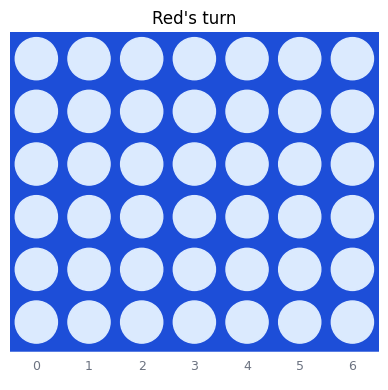

In [25]:
board_hvh = initial_state()
fig_hvh, ax_hvh = plt.subplots(figsize=(5, 4))
fig_hvh.canvas.header_visible = False
draw_board(ax_hvh, board_hvh, "Red's turn")

def _status_hvh():
    if not TERMINAL(board_hvh):
        return "Red's turn" if PLAYER(board_hvh) == 1 else "Yellow's turn"
    u = UTILITY(board_hvh)
    return 'Red wins!' if u == 1 else ('Yellow wins!' if u == -1 else 'Draw!')

def onclick_hvh(event):
    global board_hvh
    if event.inaxes != ax_hvh or TERMINAL(board_hvh): return
    x = event.xdata
    if x is None or not (0 <= x < COLS): return
    col = int(x)
    if col not in ACTIONS(board_hvh): return
    board_hvh = RESULT(board_hvh, col)
    draw_board(ax_hvh, board_hvh, _status_hvh())
    fig_hvh.canvas.draw()

fig_hvh.canvas.mpl_connect('button_press_event', onclick_hvh)
plt.tight_layout()
plt.show()

In [26]:
# --- RESET Human vs Human ---
board_hvh = initial_state()
draw_board(ax_hvh, board_hvh, "Red's turn")
fig_hvh.canvas.draw()

In [27]:
# --- HOMEWORK TASK: IMPLEMENT ALPHA-BETA PRUNING ---

def minimax(board, depth, alpha, beta, maximizing):

    global nodes_visited
    nodes_visited += 1

    # terminal state
    if TERMINAL(board):
        return UTILITY(board) * 1_000_000, None

    # depth cutoff
    if depth == 0:
        return heuristic(board), None

    valid_cols = [c for c in _COL_ORDER if c in ACTIONS(board)]

    # MAXIMIZING PLAYER (Red)
    if maximizing:

        max_eval = -float('inf')
        best_col = valid_cols[0]

        for col in valid_cols:

            eval_score, _ = minimax(
                RESULT(board, col),
                depth - 1,
                alpha,
                beta,
                False
            )

            # update best score
            if eval_score > max_eval:
                max_eval = eval_score
                best_col = col

            # update alpha
            alpha = max(alpha, max_eval)

            # pruning
            if alpha >= beta:
                break

        return max_eval, best_col

    # MINIMIZING PLAYER (Yellow)
    else:

        min_eval = float('inf')
        best_col = valid_cols[0]

        for col in valid_cols:

            eval_score, _ = minimax(
                RESULT(board, col),
                depth - 1,
                alpha,
                beta,
                True
            )

            # update best score
            if eval_score < min_eval:
                min_eval = eval_score
                best_col = col

            # update beta
            beta = min(beta, min_eval)

            # pruning
            if alpha >= beta:
                break

        return min_eval, best_col

In [30]:
_COL_ORDER = sorted(range(COLS), key=lambda c: abs(c - COLS // 2))

In [31]:
nodes_visited = 0
start = time.time()

score, move = minimax(
    initial_state(),
    depth=6,
    alpha=-float('inf'),
    beta=float('inf'),
    maximizing=True
)

end = time.time()

print("DEPTH 6")
print("Nodes:", nodes_visited)
print("Time:", end - start)

DEPTH 6
Nodes: 1370
Time: 0.42012691497802734


At depth 6, the AI explores 1370 nodes and takes approximately 0.42 seconds to decide the move. This shows a clear increase in computation compared to lower depths due to the exponential growth of the game tree.

Even with Alpha-Beta pruning, deeper searches require significantly more processing tim